<a href="https://colab.research.google.com/github/cafauzi13/ESG_SentimentAnalysis/blob/main/scripts/klasifikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline C — Fine-tuning IndoBERT: Klasifikasi Sentimen & Tag
**ESG Sentiment Analysis — Greenwashing Detection**

Pipeline ini melakukan:
1. Load `train_set_augmented.csv` + `test_set_asli.csv`
2. Fine-tune IndoBERT untuk klasifikasi **Sentimen** (Positif/Negatif/Netral)
3. Fine-tune IndoBERT untuk klasifikasi **Tag** (Environment/Social/Governance/Finance/Investigation)
4. Evaluasi final di test set murni
5. Simpan model & hasil prediksi

> ⚠️ Pastikan Runtime → Change runtime type → **GPU (T4)**

## 0. Install & Import

In [1]:
!pip install -q transformers datasets scikit-learn torch accelerate

In [2]:
import pandas as pd
import numpy as np
import torch
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cek GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Bypass PyTorch version check for loading pickle-based weights safely (CVE-2025-32434)
# Applied after imports to avoid C-level crash during import
try:
    import transformers.modeling_utils
    import transformers.utils.import_utils
    transformers.utils.import_utils.check_torch_load_is_safe = lambda: None
    transformers.modeling_utils.check_torch_load_is_safe = lambda: None
    print("✅ PyTorch safe load check bypassed successfully!")
except Exception as e:
    print(f"⚠️ Failed to bypass safe load check: {e}")


C:\Users\Pongo\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\Pongo\AppData\Local\Programs\Python\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.0.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Device: cuda
GPU: NVIDIA GeForce RTX 2050
✅ PyTorch safe load check bypassed successfully!


## 1. Mount Drive & Load Data

In [3]:
import os
import pandas as pd

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = '/content/drive/MyDrive/ESG/'
    print('✅ Berjalan di Google Colab. DRIVE_DIR set ke Google Drive.')
except ImportError:
    DRIVE_DIR = 'data/'
    print('✅ Berjalan di Lokal. DRIVE_DIR set ke data/ lokal.')

TRAIN_PATH = DRIVE_DIR + 'train_set_augmented.csv'
TEST_PATH  = DRIVE_DIR + 'test_set_asli.csv'

# Fallback: load dari GitHub jika belum ada di Drive
GITHUB_BASE = 'https://raw.githubusercontent.com/cafauzi13/ESG_SentimentAnalysis/main/data/'

# Check local paths first for robust local pipeline execution
local_train_paths = [
    'train_set_augmented.csv',
    'data/train_set_augmented.csv',
    '../data/train_set_augmented.csv',
    'scripts/data/train_set_augmented.csv',
    'scripts/train_set_augmented.csv'
]

local_test_paths = [
    'test_set_asli.csv',
    'data/test_set_asli.csv',
    '../data/test_set_asli.csv',
    'scripts/data/test_set_asli.csv',
    'scripts/test_set_asli.csv'
]

df_train = None
for path in local_train_paths:
    if os.path.exists(path):
        try:
            df_train = pd.read_csv(path)
            print(f'✅ Dataset train berhasil di-load secara lokal dari {path}! Total data: {df_train.shape[0]} baris.')
            break
        except Exception as e:
            print(f'⚠️ Gagal load train lokal dari {path}: {e}')

df_test = None
for path in local_test_paths:
    if os.path.exists(path):
        try:
            df_test = pd.read_csv(path)
            print(f'✅ Dataset test berhasil di-load secara lokal dari {path}! Total data: {df_test.shape[0]} baris.')
            break
        except Exception as e:
            print(f'⚠️ Gagal load test lokal dari {path}: {e}')

if df_train is None or df_test is None:
    if os.path.exists(TRAIN_PATH):
        df_train = pd.read_csv(TRAIN_PATH)
        df_test  = pd.read_csv(TEST_PATH)
        print('✅ Loaded dari DRIVE_DIR')
    else:
        print('⚠️ File tidak ditemukan secara lokal maupun di Drive, loading dari GitHub...')
        df_train = pd.read_csv(GITHUB_BASE + 'train_set_augmented.csv')
        df_test  = pd.read_csv(GITHUB_BASE + 'test_set_asli.csv')
        print('✅ Loaded dari GitHub')

# Bersihkan
TEXT_COL = 'Isi Berita Clean'
df_train = df_train.dropna(subset=[TEXT_COL, 'Sentiment', 'Tag'])
df_test  = df_test.dropna(subset=[TEXT_COL, 'Sentiment', 'Tag'])
df_train[TEXT_COL] = df_train[TEXT_COL].astype(str)
df_test[TEXT_COL]  = df_test[TEXT_COL].astype(str)

print(f'\nTrain: {len(df_train)} | Test: {len(df_test)}')
print(f'\nDistribusi Sentimen (Train):\n{df_train["Sentiment"].value_counts()}')
print(f'\nDistribusi Tag (Train):\n{df_train["Tag"].value_counts()}')


✅ Berjalan di Lokal. DRIVE_DIR set ke data/ lokal.


✅ Dataset train berhasil di-load secara lokal dari data/train_set_augmented.csv! Total data: 468 baris.
✅ Dataset test berhasil di-load secara lokal dari data/test_set_asli.csv! Total data: 94 baris.

Train: 468 | Test: 94

Distribusi Sentimen (Train):
Sentiment
Netral     156
Negatif    156
Positif    156
Name: count, dtype: int64

Distribusi Tag (Train):
Tag
Social           120
Environment       91
Investigation     87
Governance        85
Finance           85
Name: count, dtype: int64


## 2. Konfigurasi Global

In [4]:
# ============================================================
# KONFIGURASI — ubah sesuai kebutuhan
# ============================================================
MODEL_NAME   = 'indobenchmark/indobert-base-p1'
MAX_LEN      = 256   # panjang token per artikel
BATCH_SIZE   = 8     # turunkan ke 4 jika OOM
EPOCHS       = 5
LR           = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
OUTPUT_DIR   = DRIVE_DIR + 'models/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Model: {MODEL_NAME}')
print(f'Max Length: {MAX_LEN} | Batch: {BATCH_SIZE} | Epochs: {EPOCHS}')

Model: indobenchmark/indobert-base-p1
Max Length: 256 | Batch: 8 | Epochs: 5


## 3. Dataset Class & Tokenizer

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'✅ Tokenizer loaded: {MODEL_NAME}')

class ESGDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

✅ Tokenizer loaded: indobenchmark/indobert-base-p1


## 4. Helper: Metrics & Plot

In [6]:
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro')
    }

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + f'confusion_{title.replace(" ","_")}.png', dpi=150)
    plt.show()

def run_evaluation(trainer, test_dataset, le, task_name):
    print(f'\n{"="*50}')
    print(f'EVALUASI FINAL — {task_name}')
    print(f'{"="*50}')
    preds_output = trainer.predict(test_dataset)
    y_pred = np.argmax(preds_output.predictions, axis=1)
    y_true = preds_output.label_ids
    class_names = le.classes_
    print(classification_report(y_true, y_pred, target_names=class_names))
    plot_confusion_matrix(y_true, y_pred, class_names, task_name)
    return y_pred, y_true

## 5. Task A — Fine-tuning Klasifikasi Sentimen
Label: **Positif / Negatif / Netral**

In [7]:
# ============================================================
# ENCODE LABEL SENTIMEN
# ============================================================
le_sent = LabelEncoder()
df_train['label_sent'] = le_sent.fit_transform(df_train['Sentiment'])
df_test['label_sent']  = le_sent.transform(df_test['Sentiment'])

print(f'Kelas Sentimen: {le_sent.classes_}')
print(f'Mapping: {dict(zip(le_sent.classes_, le_sent.transform(le_sent.classes_)))}')

Kelas Sentimen: ['Negatif' 'Netral' 'Positif']
Mapping: {'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}


In [8]:
# ============================================================# BUILD DATASET
# ============================================================ 
from sklearn.model_selection import train_test_split

# Split df_train into sub-train and validation set (90/10 split, stratified by Sentiment)
df_train_sub_sent, df_val_sent = train_test_split(
    df_train,
    test_size=0.1,
    random_state=42,
    stratify=df_train['Sentiment']
)

train_sent_ds = ESGDataset(
    df_train_sub_sent[TEXT_COL].tolist(),
    df_train_sub_sent['label_sent'].tolist(),
    tokenizer, MAX_LEN
)
val_sent_ds = ESGDataset(
    df_val_sent[TEXT_COL].tolist(),
    df_val_sent['label_sent'].tolist(),
    tokenizer, MAX_LEN
)
test_sent_ds = ESGDataset(
    df_test[TEXT_COL].tolist(),
    df_test['label_sent'].tolist(),
    tokenizer, MAX_LEN
)
print(f'Train samples: {len(train_sent_ds)} | Val samples: {len(val_sent_ds)} | Test samples: {len(test_sent_ds)}')


Train samples: 421 | Val samples: 47 | Test samples: 94


In [9]:
# ============================================================
# MODEL & TRAINER SENTIMEN
# ============================================================
NUM_LABELS_SENT = len(le_sent.classes_)
model_sent = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS_SENT
)

SENT_OUTPUT = OUTPUT_DIR + 'sentiment/'
os.makedirs(SENT_OUTPUT, exist_ok=True)

args_sent = TrainingArguments(
    save_only_model=True,
    output_dir=SENT_OUTPUT,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=50,
    report_to='none',
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0
)

trainer_sent = Trainer(
    model=model_sent,
    args=args_sent,
    train_dataset=train_sent_ds,
    eval_dataset=val_sent_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print('🚀 Mulai fine-tuning Sentimen...')
trainer_sent.train()


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14229.61it/s]


[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.89it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.26it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.25it/s]

TrainOutput(global_step=265, training_loss=0.40171706676483154, metrics={'train_runtime': 102.8465, 'train_samples_per_second': 20.467, 'train_steps_per_second': 2.577, 'total_flos': 276926872158720.0, 'train_loss': 0.40171706676483154, 'epoch': 5.0})


EVALUASI FINAL — Klasifikasi Sentimen


              precision    recall  f1-score   support

     Negatif       0.92      0.92      0.92        39
      Netral       0.75      0.90      0.82        20
     Positif       0.97      0.86      0.91        35

    accuracy                           0.89        94
   macro avg       0.88      0.89      0.88        94
weighted avg       0.90      0.89      0.90        94



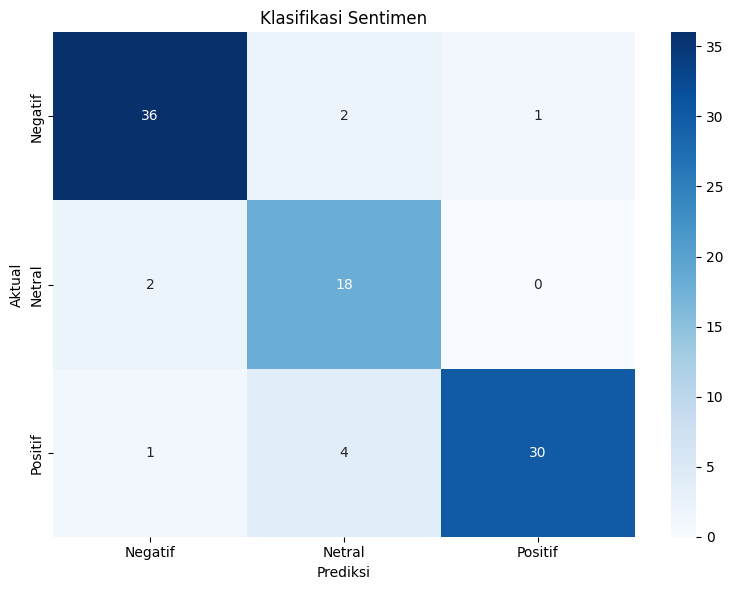

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.09it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.09it/s]


✅ Model sentimen disimpan: data/models/sentiment/best_model/


In [10]:
# ============================================================
# EVALUASI SENTIMEN
# ============================================================
y_pred_sent, y_true_sent = run_evaluation(
    trainer_sent, test_sent_ds, le_sent, 'Klasifikasi Sentimen'
)

# Simpan model terbaik
trainer_sent.save_model(SENT_OUTPUT + 'best_model/')
print(f'\n✅ Model sentimen disimpan: {SENT_OUTPUT}best_model/')

## 6. Task B — Fine-tuning Klasifikasi Tag
Label: **Environment / Social / Governance / Finance / Investigation**

In [11]:
# ============================================================
# ENCODE LABEL TAG
# ============================================================
le_tag = LabelEncoder()
df_train['label_tag'] = le_tag.fit_transform(df_train['Tag'])
df_test['label_tag']  = le_tag.transform(df_test['Tag'])

print(f'Kelas Tag: {le_tag.classes_}')
print(f'Mapping: {dict(zip(le_tag.classes_, le_tag.transform(le_tag.classes_)))}')

Kelas Tag: ['Environment' 'Finance' 'Governance' 'Investigation' 'Social']
Mapping: {'Environment': np.int64(0), 'Finance': np.int64(1), 'Governance': np.int64(2), 'Investigation': np.int64(3), 'Social': np.int64(4)}


In [12]:
# ============================================================# BUILD DATASET TAG
# ============================================================ 
from sklearn.model_selection import train_test_split

# Split df_train into sub-train and validation set (90/10 split, stratified by Tag)
df_train_sub_tag, df_val_tag = train_test_split(
    df_train,
    test_size=0.1,
    random_state=42,
    stratify=df_train['Tag']
)

train_tag_ds = ESGDataset(
    df_train_sub_tag[TEXT_COL].tolist(),
    df_train_sub_tag['label_tag'].tolist(),
    tokenizer, MAX_LEN
)
val_tag_ds = ESGDataset(
    df_val_tag[TEXT_COL].tolist(),
    df_val_tag['label_tag'].tolist(),
    tokenizer, MAX_LEN
)
test_tag_ds = ESGDataset(
    df_test[TEXT_COL].tolist(),
    df_test['label_tag'].tolist(),
    tokenizer, MAX_LEN
)
print(f'Train samples: {len(train_tag_ds)} | Val samples: {len(val_tag_ds)} | Test samples: {len(test_tag_ds)}')


Train samples: 421 | Val samples: 47 | Test samples: 94


In [13]:
# ============================================================# MODEL & TRAINER TAG
# ============================================================ 
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

NUM_LABELS_TAG = len(le_tag.classes_)
model_tag = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS_TAG
)

TAG_OUTPUT = OUTPUT_DIR + 'tag/'
os.makedirs(TAG_OUTPUT, exist_ok=True)

# Hitung bobot kelas untuk mengatasi ketidakseimbangan kelas Tag
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train_sub_tag['label_tag']),
    y=df_train_sub_tag['label_tag'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f'Bobot Kelas Tag: {class_weights}')

# Kustom Trainer dengan weighted CrossEntropyLoss
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

args_tag = TrainingArguments(
    save_only_model=True,
    output_dir=TAG_OUTPUT,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=50,
    report_to='none',
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0
)

trainer_tag = WeightedLossTrainer(
    model=model_tag,
    args=args_tag,
    train_dataset=train_tag_ds,
    eval_dataset=val_tag_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print('🚀 Mulai fine-tuning Tag dengan WeightedLossTrainer...')
trainer_tag.train()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18342.30it/s]


[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Bobot Kelas Tag: [1.02682927 1.10789474 1.09350649 1.07948718 0.77962963]
🚀 Mulai fine-tuning Tag dengan WeightedLossTrainer...


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.88it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.36it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.36it/s]

TrainOutput(global_step=265, training_loss=0.7816273563313034, metrics={'train_runtime': 411.155, 'train_samples_per_second': 5.12, 'train_steps_per_second': 0.645, 'total_flos': 276931844943360.0, 'train_loss': 0.7816273563313034, 'epoch': 5.0})


EVALUASI FINAL — Klasifikasi Tag


               precision    recall  f1-score   support

  Environment       0.57      0.57      0.57        21
      Finance       0.68      0.93      0.79        14
   Governance       0.47      0.57      0.52        14
Investigation       0.85      0.50      0.63        22
       Social       0.71      0.74      0.72        23

     accuracy                           0.65        94
    macro avg       0.66      0.66      0.65        94
 weighted avg       0.67      0.65      0.65        94



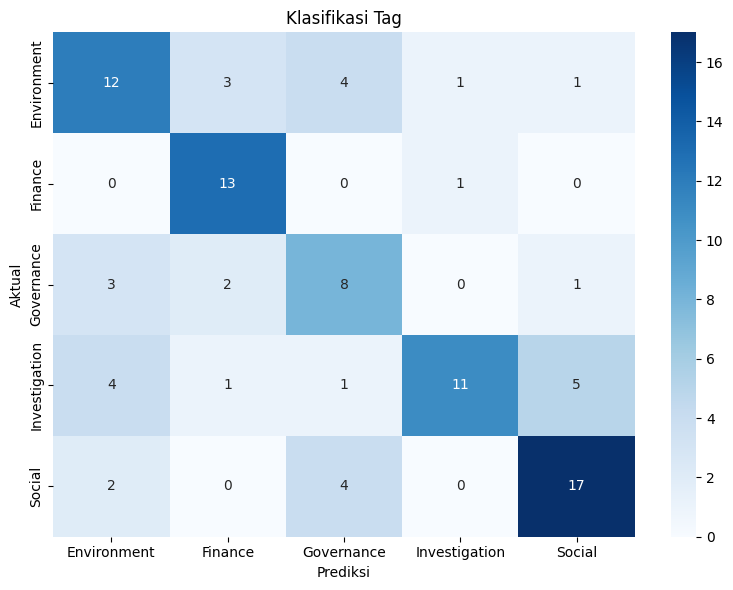

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.52it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.52it/s]


✅ Model tag disimpan: data/models/tag/best_model/


In [14]:
# ============================================================
# EVALUASI TAG
# ============================================================
y_pred_tag, y_true_tag = run_evaluation(
    trainer_tag, test_tag_ds, le_tag, 'Klasifikasi Tag'
)

trainer_tag.save_model(TAG_OUTPUT + 'best_model/')
print(f'\n✅ Model tag disimpan: {TAG_OUTPUT}best_model/')

## 7. Ringkasan Hasil & Simpan Prediksi

In [15]:
# ============================================================
# RINGKASAN PERFORMA KESELURUHAN
# ============================================================
from sklearn.metrics import f1_score, accuracy_score

acc_sent  = accuracy_score(y_true_sent, y_pred_sent)
f1_sent   = f1_score(y_true_sent, y_pred_sent, average='macro')
acc_tag   = accuracy_score(y_true_tag, y_pred_tag)
f1_tag    = f1_score(y_true_tag, y_pred_tag, average='macro')

print('=' * 55)
print('          RINGKASAN EVALUASI FINAL')
print('=' * 55)
print(f'  Task Sentimen → Accuracy: {acc_sent:.3f} | F1-Macro: {f1_sent:.3f}')
print(f'  Task Tag      → Accuracy: {acc_tag:.3f} | F1-Macro: {f1_tag:.3f}')
print('=' * 55)

threshold_met = '✅' if f1_sent >= 0.85 and f1_tag >= 0.85 else '⚠️ Belum mencapai target 85%'
print(f'\n  Target F1 ≥ 0.85: {threshold_met}')
if f1_sent < 0.85 or f1_tag < 0.85:
    print('  → Pertimbangkan: tambah epoch, turunkan LR, atau tambah data augmentasi')

          RINGKASAN EVALUASI FINAL
  Task Sentimen → Accuracy: 0.894 | F1-Macro: 0.883
  Task Tag      → Accuracy: 0.649 | F1-Macro: 0.645

  Target F1 ≥ 0.85: ⚠️ Belum mencapai target 85%
  → Pertimbangkan: tambah epoch, turunkan LR, atau tambah data augmentasi


In [16]:
# ============================================================
# SIMPAN PREDIKSI KE CSV
# ============================================================
df_result = df_test.copy()
df_result['pred_sentiment']     = le_sent.inverse_transform(y_pred_sent)
df_result['pred_tag']           = le_tag.inverse_transform(y_pred_tag)
df_result['correct_sentiment']  = df_result['Sentiment'] == df_result['pred_sentiment']
df_result['correct_tag']        = df_result['Tag'] == df_result['pred_tag']

RESULT_PATH = OUTPUT_DIR + 'test_predictions.csv'
df_result.to_csv(RESULT_PATH, index=False)
print(f'✅ Prediksi disimpan: {RESULT_PATH}')
print(f'\nContoh hasil prediksi:')
df_result[['Sentiment', 'pred_sentiment', 'correct_sentiment',
           'Tag', 'pred_tag', 'correct_tag']].head(10)

✅ Prediksi disimpan: data/models/test_predictions.csv

Contoh hasil prediksi:


,Sentiment,pred_sentiment,correct_sentiment,Tag,pred_tag,correct_tag
0,Positif,Positif,True,Finance,Finance,True
1,Positif,Positif,True,Governance,Finance,False
2,Positif,Positif,True,Finance,Finance,True
3,Positif,Positif,True,Environment,Finance,False
4,Positif,Positif,True,Environment,Environment,True
5,Positif,Netral,False,Investigation,Investigation,True
6,Negatif,Negatif,True,Environment,Environment,True
7,Positif,Positif,True,Finance,Finance,True
8,Positif,Positif,True,Governance,Environment,False
9,Positif,Netral,False,Governance,Governance,True


## 8. [BONUS] Training History Plot
Visualisasi loss dan F1 per epoch

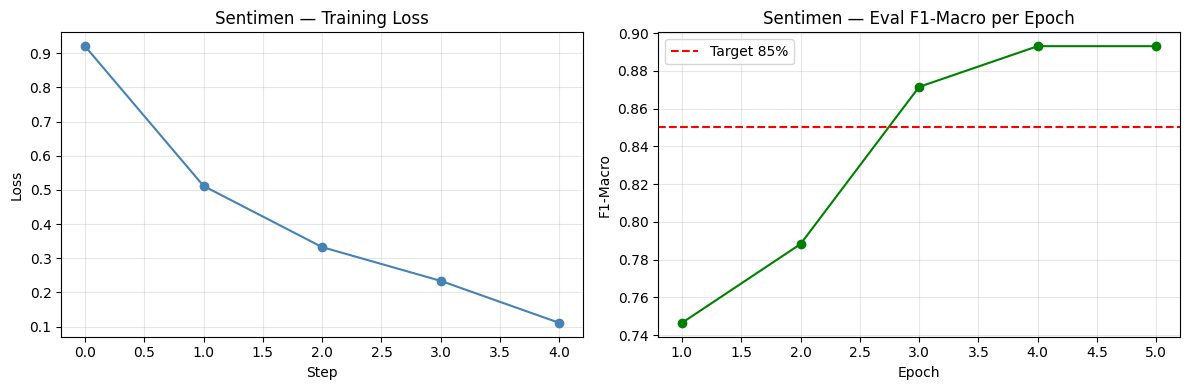

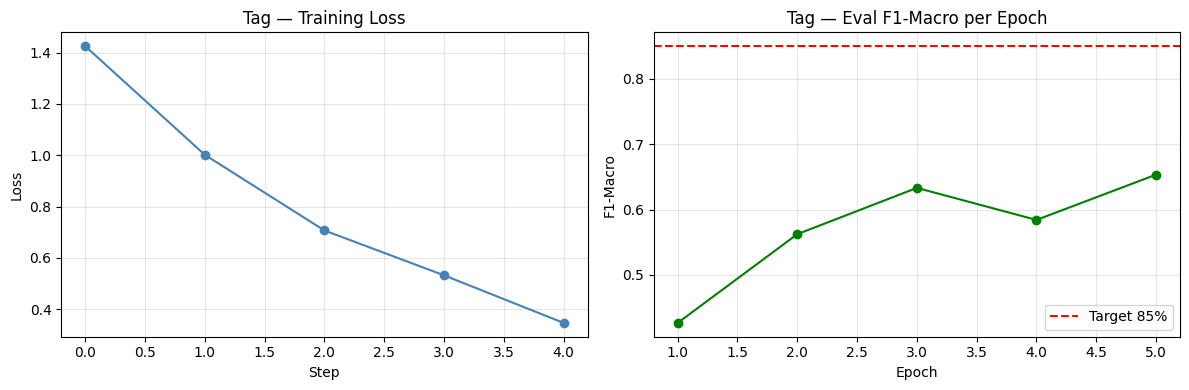

In [17]:
def plot_training_history(trainer, title):
    logs = trainer.state.log_history
    train_loss, eval_f1, epochs = [], [], []

    for log in logs:
        if 'loss' in log and 'epoch' in log:
            train_loss.append(log['loss'])
        if 'eval_f1_macro' in log:
            eval_f1.append(log['eval_f1_macro'])
            epochs.append(log['epoch'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(train_loss, marker='o', color='steelblue')
    ax1.set_title(f'{title} — Training Loss')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, eval_f1, marker='o', color='green')
    ax2.axhline(y=0.85, color='red', linestyle='--', label='Target 85%')
    ax2.set_title(f'{title} — Eval F1-Macro per Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1-Macro')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + f'history_{title.replace(" ","_")}.png', dpi=150)
    plt.show()

plot_training_history(trainer_sent, 'Sentimen')
plot_training_history(trainer_tag, 'Tag')

---
## ✅ Checklist Setelah Menjalankan Notebook Ini

| Item | Status |
|------|--------|
| Fine-tuning sentimen selesai | ☐ |
| Fine-tuning tag selesai | ☐ |
| F1-Macro sentimen ≥ 0.85 | ☐ |
| F1-Macro tag ≥ 0.85 | ☐ |
| Model disimpan ke Drive | ☐ |
| `test_predictions.csv` tersimpan | ☐ |

**Jika F1 < 0.85**, coba:
- Naikkan `EPOCHS` ke 7–10
- Turunkan `LR` ke `1e-5`
- Turunkan `MAX_LEN` ke 128 (lebih cepat, lebih banyak iterasi)
- Tambah data augmentasi untuk kelas yang performanya rendah